# Options Strategy Recommendation and Optimisation System
## Notebook 3 - Knowledge Graph and Rule Reasoning

This notebook converts Notebook 2 features into an explainable ranking of option-strategy families. It uses an RDF knowledge graph for domain relationships and transparent rules for inference.

Supported strategies: **Bull Call Spread, Bull Put Spread, Bear Put Spread, Bear Call Spread, Long Call, and Long Put**.

## Intelligent-reasoning role

This notebook demonstrates two IRS technique groups:

- **Knowledge-based reasoning:** an RDF graph represents outlooks, market states, volatility regimes, strategies and their relationships.
- **Decision automation:** explicit rules score and rank strategies, with every adjustment recorded in a reasoning trace.

The output recommends strategy **families**, not specific contracts. Notebook 4 will construct and evaluate exact option legs.

## 1. Environment setup

If required, install packages once with: `pip install pandas numpy matplotlib networkx rdflib`.

In [4]:
from __future__ import annotations

import json
import math
import re
import sys
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display
from rdflib import Graph, Literal, Namespace, RDF, RDFS, URIRef
from rdflib.namespace import XSD

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
print(f"Python: {sys.version.split()[0]} | pandas: {pd.__version__} | NetworkX: {nx.__version__}")

Python: 3.9.23 | pandas: 2.3.2 | NetworkX: 3.2.1


## 2. Configuration and Notebook 2 inputs

In [6]:
TICKER = "CRM"
OUTLOOK = "bullish"  # allowed: bullish, bearish


In [7]:
NOTEBOOK2_ROOT = Path("outputs/notebook_02")
NOTEBOOK3_ROOT = Path("outputs/notebook_03")
TOP_STRATEGY_COUNT = 3

def validate_settings(ticker: str, outlook: str) -> tuple[str, str]:
    ticker = ticker.strip().upper().replace(".", "-")
    outlook = outlook.strip().lower()
    if not ticker or not re.fullmatch(r"[A-Z0-9^=-]{1,15}", ticker):
        raise ValueError("Ticker is empty or contains unsupported characters.")
    if outlook not in {"bullish", "bearish"}:
        raise ValueError("OUTLOOK must be either 'bullish' or 'bearish'.")
    return ticker, outlook

ticker, outlook = validate_settings(TICKER, OUTLOOK)
run_name = f"{ticker}_{outlook}"
NOTEBOOK2_DIR = NOTEBOOK2_ROOT / ticker
OUTPUT_DIR = NOTEBOOK3_ROOT / ticker / outlook
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
input_paths = {
    "feature_snapshot": NOTEBOOK2_DIR / "feature_snapshot.json",
    "option_features": NOTEBOOK2_DIR / "option_features.csv",
    "expiry_features": NOTEBOOK2_DIR / "expiry_features.csv",
}
input_paths


{'feature_snapshot': WindowsPath('outputs/notebook_02/CRM/feature_snapshot.json'),
 'option_features': WindowsPath('outputs/notebook_02/CRM/option_features.csv'),
 'expiry_features': WindowsPath('outputs/notebook_02/CRM/expiry_features.csv')}

In [8]:
missing_files = [str(path) for path in input_paths.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Notebook 2 outputs were not found. Run Notebooks 1 and 2 with the same ticker first. Missing: "
        + ", ".join(missing_files)
    )

with input_paths["feature_snapshot"].open("r", encoding="utf-8") as file:
    feature_snapshot = json.load(file)
option_features = pd.read_csv(input_paths["option_features"])
expiry_features = pd.read_csv(input_paths["expiry_features"])

if feature_snapshot.get("request") != {"ticker": ticker}:
    raise ValueError("Notebook 2 snapshot does not match the configured ticker.")
if option_features.empty or expiry_features.empty:
    raise ValueError("Notebook 2 returned an empty option or expiry feature dataset.")

underlying = feature_snapshot["underlying_features"]
print(f"Loaded {len(option_features):,} contracts across {len(expiry_features):,} expiries.")
display(expiry_features)
observed_direction = str(underlying.get("observed_direction", "neutral"))
alignment = (
    "aligned" if observed_direction == outlook
    else "conflicting" if observed_direction in {"bullish", "bearish"}
    else "neutral"
)


Loaded 61 contracts across 3 expiries.


,expiry,dte,dte_bucket,spot_price,atm_contract_count,atm_implied_volatility,historical_vol_20,iv_to_hv_ratio,volatility_regime,expected_move_pct,expected_move,expected_lower_price,expected_upper_price,median_liquidity_score,candidate_contract_count
0,2026-09-25,26,short_1_30,252.050,2,0.414,0.791,0.524,low_iv_relative_to_hv,0.111,27.871,224.179,279.921,50.441,13
1,2026-10-02,33,medium_31_60,252.050,3,0.424,0.791,0.537,low_iv_relative_to_hv,0.128,32.163,219.887,284.213,50.000,9
2,2026-10-16,47,medium_31_60,252.050,2,0.406,0.791,0.514,low_iv_relative_to_hv,0.146,36.747,215.303,288.797,52.283,24


## 3. Strategy knowledge base

Each strategy is described independently of the current stock. This reusable knowledge becomes graph nodes and rule-engine candidates.

In [10]:
@dataclass(frozen=True)
class StrategyDefinition:
    strategy_id: str
    name: str
    direction: str
    premium_style: str
    leg_count: int
    max_risk: str
    max_profit: str
    preferred_volatility: str
    description: str

STRATEGIES = [
    StrategyDefinition("bull_call_spread", "Bull Call Spread", "bullish", "debit", 2, "limited", "limited", "low_or_balanced", "Buy a lower-strike call and sell a higher-strike call."),
    StrategyDefinition("bull_put_spread", "Bull Put Spread", "bullish", "credit", 2, "limited", "limited", "elevated_or_high", "Sell a higher-strike put and buy a lower-strike put."),
    StrategyDefinition("long_call", "Long Call", "bullish", "debit", 1, "limited", "unlimited", "low_or_balanced", "Buy a call to express a bullish view with limited premium risk."),
    StrategyDefinition("bear_put_spread", "Bear Put Spread", "bearish", "debit", 2, "limited", "limited", "low_or_balanced", "Buy a higher-strike put and sell a lower-strike put."),
    StrategyDefinition("bear_call_spread", "Bear Call Spread", "bearish", "credit", 2, "limited", "limited", "elevated_or_high", "Sell a lower-strike call and buy a higher-strike call."),
    StrategyDefinition("long_put", "Long Put", "bearish", "debit", 1, "limited", "substantial", "low_or_balanced", "Buy a put to express a bearish view with limited premium risk."),
]
strategy_catalog = pd.DataFrame([asdict(strategy) for strategy in STRATEGIES])
display(strategy_catalog)

,strategy_id,name,direction,premium_style,leg_count,max_risk,max_profit,preferred_volatility,description
0,bull_call_spread,Bull Call Spread,bullish,debit,2,limited,limited,low_or_balanced,Buy a lower-strike call and sell a higher-strike call.
1,bull_put_spread,Bull Put Spread,bullish,credit,2,limited,limited,elevated_or_high,Sell a higher-strike put and buy a lower-strike put.
2,long_call,Long Call,bullish,debit,1,limited,unlimited,low_or_balanced,Buy a call to express a bullish view with limited premium risk.
3,bear_put_spread,Bear Put Spread,bearish,debit,2,limited,limited,low_or_balanced,Buy a higher-strike put and sell a lower-strike put.
4,bear_call_spread,Bear Call Spread,bearish,credit,2,limited,limited,elevated_or_high,Sell a lower-strike call and buy a higher-strike call.
5,long_put,Long Put,bearish,debit,1,limited,substantial,low_or_balanced,Buy a put to express a bearish view with limited premium risk.


## 4. Build the RDF knowledge graph

The graph combines reusable domain knowledge with the current request and observed market state.

In [12]:
OPT = Namespace("http://example.org/options#")
graph = Graph()
graph.bind("opt", OPT)

classes = ["UserRequest", "MarketState", "Direction", "TrendState", "VolatilityRegime", "StrategyFamily"]
for class_name in classes:
    graph.add((OPT[class_name], RDF.type, RDFS.Class))

bullish_node, bearish_node = OPT.Bullish, OPT.Bearish
graph.add((bullish_node, RDF.type, OPT.Direction))
graph.add((bearish_node, RDF.type, OPT.Direction))

for strategy in STRATEGIES:
    node = OPT[strategy.strategy_id]
    graph.add((node, RDF.type, OPT.StrategyFamily))
    graph.add((node, RDFS.label, Literal(strategy.name)))
    graph.add((node, OPT.supportsDirection, bullish_node if strategy.direction == "bullish" else bearish_node))
    graph.add((node, OPT.hasPremiumStyle, Literal(strategy.premium_style)))
    graph.add((node, OPT.hasLegCount, Literal(strategy.leg_count, datatype=XSD.integer)))
    graph.add((node, OPT.prefersVolatility, Literal(strategy.preferred_volatility)))
    graph.add((node, OPT.hasLimitedRisk, Literal(strategy.max_risk == "limited", datatype=XSD.boolean)))

request_node = OPT[f"request_{run_name}"]
market_node = OPT[f"market_{ticker}"]
graph.add((request_node, RDF.type, OPT.UserRequest))
graph.add((request_node, OPT.hasTicker, Literal(ticker)))
graph.add((request_node, OPT.hasOutlook, bullish_node if outlook == "bullish" else bearish_node))
graph.add((request_node, OPT.observesMarket, market_node))
graph.add((market_node, RDF.type, OPT.MarketState))
graph.add((market_node, OPT.hasTrendLabel, Literal(underlying["trend_label"])))
graph.add((market_node, OPT.hasTrendScore, Literal(float(underlying["trend_score"]), datatype=XSD.double)))
graph.add((market_node, OPT.hasOutlookAlignment, Literal(alignment)))

for row in expiry_features.itertuples(index=False):
    expiry_node = OPT[f"expiry_{str(row.expiry).replace('-', '')}"]
    graph.add((market_node, OPT.hasExpiryState, expiry_node))
    graph.add((expiry_node, OPT.hasDTE, Literal(int(row.dte), datatype=XSD.integer)))
    graph.add((expiry_node, OPT.hasVolatilityRegime, Literal(row.volatility_regime)))
    graph.add((expiry_node, OPT.hasExpectedMove, Literal(float(row.expected_move), datatype=XSD.double)))
    graph.add((expiry_node, OPT.hasCandidateCount, Literal(int(row.candidate_contract_count), datatype=XSD.integer)))

print(f"Knowledge graph created with {len(graph):,} RDF triples.")

Knowledge graph created with 73 RDF triples.


In [13]:
def compact_term(term: Any) -> str:
    text = str(term)
    return text.replace(str(OPT), "opt:") if text.startswith(str(OPT)) else text

knowledge_graph_triples = pd.DataFrame(
    [(compact_term(s), compact_term(p), compact_term(o)) for s, p, o in graph],
    columns=["subject", "predicate", "object"]
).sort_values(["subject", "predicate", "object"]).reset_index(drop=True)
display(knowledge_graph_triples.head(15))

,subject,predicate,object
0,opt:Bearish,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,opt:Direction
1,opt:Bullish,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,opt:Direction
2,opt:Direction,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.w3.org/2000/01/rdf-schema#Class
3,opt:MarketState,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.w3.org/2000/01/rdf-schema#Class
4,opt:StrategyFamily,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.w3.org/2000/01/rdf-schema#Class
5,opt:TrendState,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.w3.org/2000/01/rdf-schema#Class
6,opt:UserRequest,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.w3.org/2000/01/rdf-schema#Class
7,opt:VolatilityRegime,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.w3.org/2000/01/rdf-schema#Class
8,opt:bear_call_spread,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,opt:StrategyFamily
9,opt:bear_call_spread,http://www.w3.org/2000/01/rdf-schema#label,Bear Call Spread


## 5. Explainable rule engine

Core rules use the user's direction and the selected expiry's volatility regime. Trend alignment and liquidity adjust, but do not silently replace, the user's stated outlook.

In [15]:
def choose_expiry(expiries: pd.DataFrame) -> pd.Series:
    candidates = expiries.loc[expiries["dte"].between(21, 60)].copy()
    if candidates.empty:
        candidates = expiries.copy()
    candidates["expiry_selection_score"] = (
        candidates["candidate_contract_count"].rank(pct=True) * 60
        + candidates["median_liquidity_score"].rank(pct=True) * 40
    )
    return candidates.sort_values(["expiry_selection_score", "dte"], ascending=[False, True]).iloc[0]

selected_expiry = choose_expiry(expiry_features)
volatility_regime = str(selected_expiry["volatility_regime"])
high_iv = volatility_regime in {"elevated_iv", "high_iv"}
alignment = str(alignment)
median_liquidity = float(selected_expiry["median_liquidity_score"])

BASE_SCORES = {
    ("bullish", False): {"bull_call_spread": 95, "long_call": 85, "bull_put_spread": 55},
    ("bullish", True): {"bull_put_spread": 100, "bull_call_spread": 75, "long_call": 45},
    ("bearish", False): {"bear_put_spread": 95, "long_put": 85, "bear_call_spread": 55},
    ("bearish", True): {"bear_call_spread": 100, "bear_put_spread": 75, "long_put": 45},
}

trace: list[dict[str, Any]] = []
rank_rows: list[dict[str, Any]] = []
direction_candidates = [strategy for strategy in STRATEGIES if strategy.direction == outlook]
for strategy in direction_candidates:
    score = float(BASE_SCORES[(outlook, high_iv)][strategy.strategy_id])
    reasons = [f"Direction rule: {strategy.name} supports the user's {outlook} outlook."]
    trace.append({"strategy_id": strategy.strategy_id, "rule": "direction_and_volatility", "adjustment": score, "detail": reasons[-1]})

    vol_reason = (
        f"{volatility_regime} favours premium-credit structures." if high_iv and strategy.premium_style == "credit"
        else f"{volatility_regime} favours debit structures." if not high_iv and strategy.premium_style == "debit"
        else f"{volatility_regime} is less favourable for this {strategy.premium_style} structure."
    )
    reasons.append(vol_reason)

    alignment_adjustment = 10 if alignment == "aligned" else -20 if alignment == "conflicting" else 0
    score += alignment_adjustment
    reasons.append(f"Trend alignment is {alignment} ({alignment_adjustment:+.0f} points).")
    trace.append({"strategy_id": strategy.strategy_id, "rule": "trend_alignment", "adjustment": alignment_adjustment, "detail": reasons[-1]})

    liquidity_adjustment = 10 if median_liquidity >= 75 else 5 if median_liquidity >= 50 else -15 if median_liquidity < 25 else 0
    score += liquidity_adjustment
    reasons.append(f"Median expiry liquidity is {median_liquidity:.1f}/100 ({liquidity_adjustment:+.0f} points).")
    trace.append({"strategy_id": strategy.strategy_id, "rule": "liquidity", "adjustment": liquidity_adjustment, "detail": reasons[-1]})

    if strategy.leg_count == 2 and int(selected_expiry["candidate_contract_count"]) < 4:
        score -= 20
        reasons.append("Fewer than four quality contracts may restrict two-leg construction (-20 points).")
        trace.append({"strategy_id": strategy.strategy_id, "rule": "contract_availability", "adjustment": -20, "detail": reasons[-1]})

    rank_rows.append({
        **asdict(strategy),
        "selected_expiry": selected_expiry["expiry"],
        "selected_dte": int(selected_expiry["dte"]),
        "volatility_regime": volatility_regime,
        "outlook_alignment": alignment,
        "reasoning_score": float(np.clip(score, 0, 120)),
        "explanation": " | ".join(reasons),
    })

ranked_strategies = (
    pd.DataFrame(rank_rows).sort_values(["reasoning_score", "name"], ascending=[False, True]).reset_index(drop=True)
)
ranked_strategies.insert(0, "rank", np.arange(1, len(ranked_strategies) + 1))
ranked_strategies["recommended_for_next_stage"] = ranked_strategies["rank"].le(TOP_STRATEGY_COUNT)
display(ranked_strategies[["rank", "name", "reasoning_score", "selected_expiry", "volatility_regime", "explanation"]])

,rank,name,reasoning_score,selected_expiry,volatility_regime,explanation
0,1,Bull Call Spread,110.000,2026-10-16,low_iv_relative_to_hv,Direction rule: Bull Call Spread supports the user's bullish outlook. | low_iv_relative_to_hv favours debit structures. | Trend alignment is aligned (+10 po...
1,2,Long Call,100.000,2026-10-16,low_iv_relative_to_hv,Direction rule: Long Call supports the user's bullish outlook. | low_iv_relative_to_hv favours debit structures. | Trend alignment is aligned (+10 points). ...
2,3,Bull Put Spread,70.000,2026-10-16,low_iv_relative_to_hv,Direction rule: Bull Put Spread supports the user's bullish outlook. | low_iv_relative_to_hv is less favourable for this credit structure. | Trend alignment...


## 6. Add inferred recommendations to the graph

In [17]:
for row in ranked_strategies.itertuples(index=False):
    strategy_node = OPT[row.strategy_id]
    recommendation_node = OPT[f"recommendation_{run_name}_{row.strategy_id}"]
    graph.add((recommendation_node, RDF.type, OPT.Recommendation))
    graph.add((recommendation_node, OPT.recommendsStrategy, strategy_node))
    graph.add((recommendation_node, OPT.hasReasoningScore, Literal(float(row.reasoning_score), datatype=XSD.double)))
    graph.add((recommendation_node, OPT.hasRank, Literal(int(row.rank), datatype=XSD.integer)))
    graph.add((recommendation_node, OPT.forRequest, request_node))
    if row.recommended_for_next_stage:
        graph.add((request_node, OPT.hasRecommendedStrategy, strategy_node))

knowledge_graph_triples = pd.DataFrame(
    [(compact_term(s), compact_term(p), compact_term(o)) for s, p, o in graph],
    columns=["subject", "predicate", "object"]
).sort_values(["subject", "predicate", "object"]).reset_index(drop=True)
print(f"Graph after inference: {len(graph):,} triples.")

Graph after inference: 91 triples.


## 7. Visualise the reasoning graph and ranking

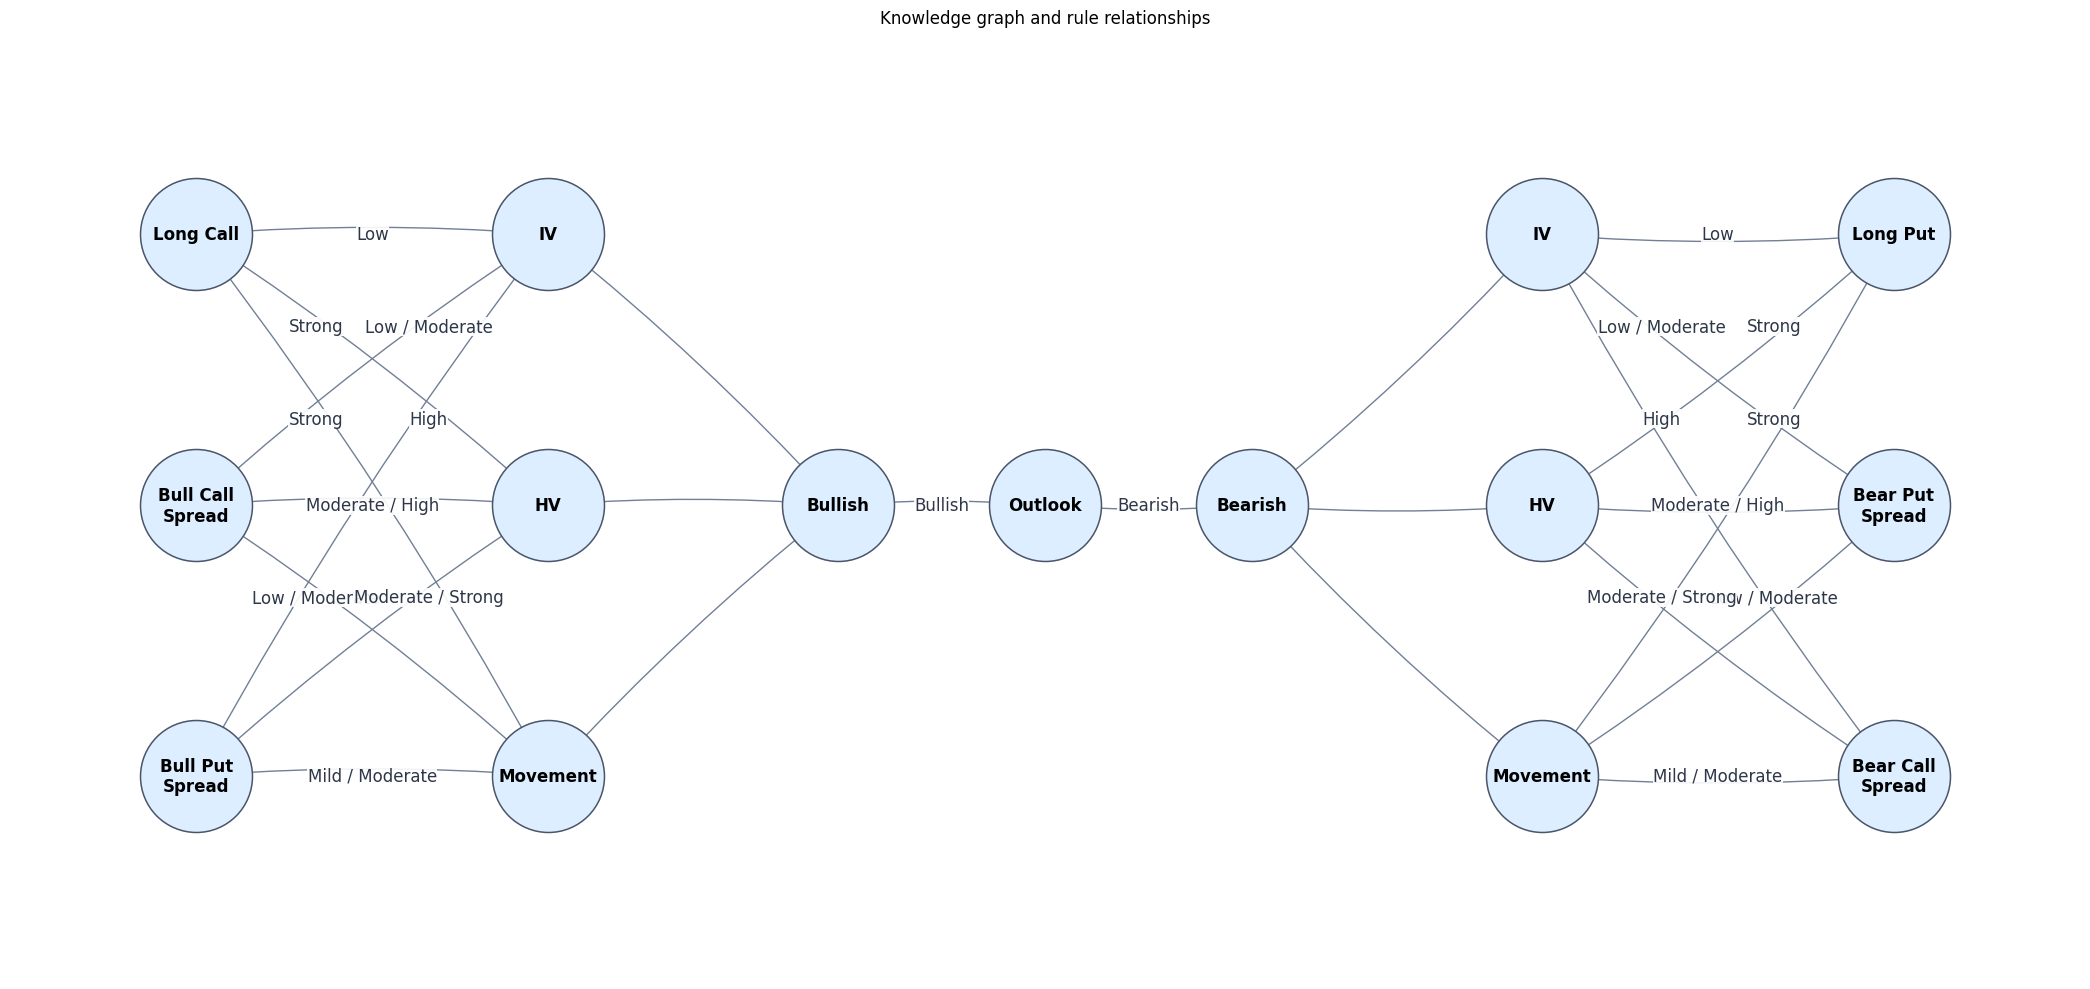

In [37]:
from textwrap import fill

fig, graph_ax = plt.subplots(figsize=(21, 10))

metrics = ("IV", "HV", "Movement")
families = {
    "bullish": ["long_call", "bull_call_spread", "bull_put_spread"],
    "bearish": ["long_put", "bear_put_spread", "bear_call_spread"],
}
relationships = {
    "IV": ("Low", "Low / Moderate", "High"),
    "HV": ("Strong", "Moderate / High", "Moderate / Strong"),
    "Movement": ("Strong", "Low / Moderate", "Mild / Moderate"),
}
strategy_labels = strategy_catalog.set_index("strategy_id")["name"].to_dict()

plot_graph = nx.DiGraph()
plot_graph.add_node("Outlook", label="Outlook")
positions, edge_notes = {"Outlook": (0, 0)}, []

for direction, side in (("bullish", -1), ("bearish", 1)):
    branch = direction.title()
    plot_graph.add_node(branch, label=branch)
    plot_graph.add_edge("Outlook", branch)
    positions[branch] = (2 * side, 0)
    edge_notes.append(("Outlook", branch, branch, 0.5))

    for y, metric in zip((1.6, 0, -1.6), metrics):
        node = f"{direction}_{metric.lower()}"
        plot_graph.add_node(node, label=metric)
        plot_graph.add_edge(branch, node)
        positions[node] = (4.8 * side, y)

    for target_index, (y, strategy_id) in enumerate(
        zip((1.6, 0, -1.6), families[direction])
    ):
        node = f"{direction}_{strategy_id}"
        plot_graph.add_node(node, label=fill(strategy_labels[strategy_id], 13))
        positions[node] = (8.2 * side, y)

        for source_index, (metric, values) in enumerate(relationships.items()):
            source = f"{direction}_{metric.lower()}"
            plot_graph.add_edge(source, node)
            portion = 0.5 if source_index == target_index else (
                0.34 if target_index > source_index else 0.66
            )
            edge_notes.append((source, node, values[target_index], portion))

nx.draw_networkx_edges(
    plot_graph, positions, ax=graph_ax, edge_color="#718096", width=1.0,
    arrows=True, arrowsize=15, connectionstyle="arc3,rad=0.04"
)
nx.draw_networkx_nodes(
    plot_graph, positions, ax=graph_ax, node_size=6500, node_color="#DCEEFF",
    edgecolors="#4A5568", linewidths=1.1
)
nx.draw_networkx_labels(
    plot_graph, positions, labels=nx.get_node_attributes(plot_graph, "label"),
    ax=graph_ax, font_size=12, font_weight="bold"
)

for source, target, label, portion in edge_notes:
    x0, y0 = positions[source]
    x1, y1 = positions[target]
    graph_ax.text(
        x0 + portion * (x1 - x0), y0 + portion * (y1 - y0), label,
        ha="center", va="center", fontsize=12, color="#2D3748",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.9, "pad": 0.2},
    )

graph_ax.set(
    xlim=(-10, 10), ylim=(-2.8, 2.8), title="Knowledge graph and rule relationships"
)
graph_ax.axis("off")
fig.tight_layout()
plt.show()

## 8. Reasoning-quality checks

In [21]:
expected_direction_ids = {strategy.strategy_id for strategy in STRATEGIES if strategy.direction == outlook}
quality_checks = {
    "six_strategy_definitions_exist": len(strategy_catalog) == 6,
    "all_catalog_strategies_have_limited_risk": bool(strategy_catalog["max_risk"].eq("limited").all()),
    "three_directional_strategies_ranked": set(ranked_strategies["strategy_id"]) == expected_direction_ids,
    "ranking_is_unique_and_complete": ranked_strategies["rank"].tolist() == list(range(1, len(ranked_strategies) + 1)),
    "scores_are_bounded": bool(ranked_strategies["reasoning_score"].between(0, 120).all()),
    "every_strategy_has_explanation": bool(ranked_strategies["explanation"].str.len().gt(20).all()),
    "reasoning_trace_is_not_empty": len(trace) >= len(ranked_strategies) * 3,
    "selected_expiry_has_quality_contracts": int(selected_expiry["candidate_contract_count"]) > 0,
    "knowledge_graph_has_domain_and_inference_triples": len(graph) >= 60,
    "top_strategies_marked_for_next_stage": int(ranked_strategies["recommended_for_next_stage"].sum()) == min(TOP_STRATEGY_COUNT, len(ranked_strategies)),
}
reasoning_quality_report = pd.DataFrame(
    [{"check": name, "passed": bool(passed)} for name, passed in quality_checks.items()]
)
display(reasoning_quality_report)
failed = reasoning_quality_report.loc[~reasoning_quality_report["passed"], "check"].tolist()
if failed:
    raise AssertionError(f"Reasoning-quality checks failed: {failed}")
print("All reasoning-quality checks passed.")

,check,passed
0,six_strategy_definitions_exist,True
1,all_catalog_strategies_have_limited_risk,True
2,three_directional_strategies_ranked,True
3,ranking_is_unique_and_complete,True
4,scores_are_bounded,True
5,every_strategy_has_explanation,True
6,reasoning_trace_is_not_empty,True
7,selected_expiry_has_quality_contracts,True
8,knowledge_graph_has_domain_and_inference_triples,True
9,top_strategies_marked_for_next_stage,True


All reasoning-quality checks passed.


## 9. Export knowledge and reasoning outputs

In [23]:
export_paths = {
    "strategy_catalog": OUTPUT_DIR / "strategy_catalog.csv",
    "ranked_strategies": OUTPUT_DIR / "ranked_strategy_families.csv",
    "knowledge_graph_triples": OUTPUT_DIR / "knowledge_graph_triples.csv",
    "knowledge_graph_rdf": OUTPUT_DIR / "knowledge_graph.ttl",
    "reasoning_trace": OUTPUT_DIR / "reasoning_trace.json",
    "reasoning_quality_report": OUTPUT_DIR / "reasoning_quality_report.csv",
}
strategy_catalog.to_csv(export_paths["strategy_catalog"], index=False)
ranked_strategies.to_csv(export_paths["ranked_strategies"], index=False)
knowledge_graph_triples.to_csv(export_paths["knowledge_graph_triples"], index=False)
reasoning_quality_report.to_csv(export_paths["reasoning_quality_report"], index=False)
graph.serialize(destination=str(export_paths["knowledge_graph_rdf"]), format="turtle")
with export_paths["reasoning_trace"].open("w", encoding="utf-8") as file:
    json.dump({
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "request": {"ticker": ticker, "outlook": outlook},
        "selected_expiry": selected_expiry.to_dict(),
        "ranked_strategies": ranked_strategies.to_dict(orient="records"),
        "rule_trace": trace,
    }, file, indent=2, default=lambda value: value.item() if hasattr(value, "item") else str(value), allow_nan=False)

export_manifest = pd.DataFrame([
    {"dataset": name, "path": str(path), "exists": path.exists()}
    for name, path in export_paths.items()
])
display(export_manifest)
success_marker = OUTPUT_DIR / "_SUCCESS.json"
success_marker.write_text(json.dumps({
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "request": {"ticker": ticker, "outlook": outlook},
    "notebook": "03_Knowledge_Graph_and_Rule_Reasoning.ipynb",
}, indent=2), encoding="utf-8")
print(f"Completion marker: {success_marker}")


,dataset,path,exists
0,strategy_catalog,outputs\notebook_03\CRM\bullish\strategy_catalog.csv,True
1,ranked_strategies,outputs\notebook_03\CRM\bullish\ranked_strategy_families.csv,True
2,knowledge_graph_triples,outputs\notebook_03\CRM\bullish\knowledge_graph_triples.csv,True
3,knowledge_graph_rdf,outputs\notebook_03\CRM\bullish\knowledge_graph.ttl,True
4,reasoning_trace,outputs\notebook_03\CRM\bullish\reasoning_trace.json,True
5,reasoning_quality_report,outputs\notebook_03\CRM\bullish\reasoning_quality_report.csv,True


Completion marker: outputs\notebook_03\CRM\bullish\_SUCCESS.json


## Notebook 3 completion criteria

Notebook 3 is complete when all ten reasoning-quality checks pass and six output files are created. Notebook 4 can then take the ranked strategy families and selected expiry to construct exact legs, calculate payoff profiles, and reject structurally invalid combinations.